In [2]:
import zipfile, os

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall(".")

print("Files extracted!")

contents = os.listdir(".")
print("Current directory contents:", contents)

if "archive" in contents:
    for f in os.listdir("archive"):
        size_mb = os.path.getsize(f"archive/{f}") / (1024*1024)
        print(f"  archive/{f}  —  {size_mb:.1f} MB")

Files extracted!
Current directory contents: ['.config', 'probe.txt', 'README', 'combined_data_2.txt', 'archive.zip', 'combined_data_3.txt', 'combined_data_1.txt', 'movie_titles.csv', 'combined_data_4.txt', 'qualifying.txt', 'sample_data']


In [3]:
# DATA-LOADING AND PREPROCESSING

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [5]:
def parse_netflix_file(filepath, max_rows=None):
    """
    Parses Netflix Prize data files.
    Each movie starts with 'MovieID:' line, followed by 'UserID,Rating,Date' lines.
    Returns a list of [movie_id, user_id, rating, date]
    """
    data = []
    current_movie = None
    rows_read = 0

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                current_movie = int(line[:-1])
            else:
                parts = line.split(',')
                user_id = int(parts[0])
                rating = int(parts[1])
                date = parts[2]
                data.append([current_movie, user_id, rating, date])
                rows_read += 1
                if max_rows and rows_read >= max_rows:
                    break

    return data

data = parse_netflix_file('combined_data_1.txt', max_rows=5_000_000)

df = pd.DataFrame(data, columns=['movie_id', 'user_id', 'rating', 'date'])
df['date'] = pd.to_datetime(df['date'])
df['rating'] = df['rating'].astype(np.int8)

print(f"Loaded {len(df):,} ratings")
print(f"Users: {df['user_id'].nunique():,}")
print(f"Movies: {df['movie_id'].nunique():,}")
print(df.head())

Loaded 5,000,000 ratings
Users: 404,478
Movies: 996
   movie_id  user_id  rating       date
0         1  1488844       3 2005-09-06
1         1   822109       5 2005-05-13
2         1   885013       4 2005-10-19
3         1    30878       4 2005-12-26
4         1   823519       3 2004-05-03


In [6]:
movies = []
with open('movie_titles.csv', 'r', encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        parts = line.split(',', 2)   # split on FIRST 2 commas only, keep rest as title
        if len(parts) == 3:
            movie_id, year, title = parts
            try:
                movies.append([int(movie_id), year.strip(), title.strip()])
            except:
                pass   # skip any malformed lines

movies_df = pd.DataFrame(movies, columns=['movie_id', 'year', 'title'])
print(f"Loaded {len(movies_df)} movies")
print(movies_df.head(10))

Loaded 17770 movies
   movie_id  year                         title
0         1  2003               Dinosaur Planet
1         2  2004    Isle of Man TT 2004 Review
2         3  1997                     Character
3         4  1994  Paula Abdul's Get Up & Dance
4         5  2004      The Rise and Fall of ECW
5         6  1997                          Sick
6         7  1992                         8 Man
7         8  2004    What the #$*! Do We Know!?
8         9  1991      Class of Nuke 'Em High 2
9        10  2001                       Fighter


In [7]:
# EXPLORATORY DATA ANALYSIS

In [8]:
print("DATASET OVERVIEW")
print(f"Total ratings:     {len(df):,}")
print(f"Unique users:      {df['user_id'].nunique():,}")
print(f"Unique movies:     {df['movie_id'].nunique():,}")
print(f"Rating range:      {df['rating'].min()} to {df['rating'].max()}")
print(f"Date range:        {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")

DATASET OVERVIEW
Total ratings:     5,000,000
Unique users:      404,478
Unique movies:     996
Rating range:      1 to 5
Date range:        1999-12-08 to 2005-12-31

Rating distribution:
rating
1     220348
2     488238
3    1429692
4    1730291
5    1131431
Name: count, dtype: int64


In [9]:
total_possible = df['user_id'].nunique() * df['movie_id'].nunique()
sparsity = 1 - (len(df) / total_possible)
print(f"Matrix Sparsity: {sparsity:.4%}")

Matrix Sparsity: 98.7589%


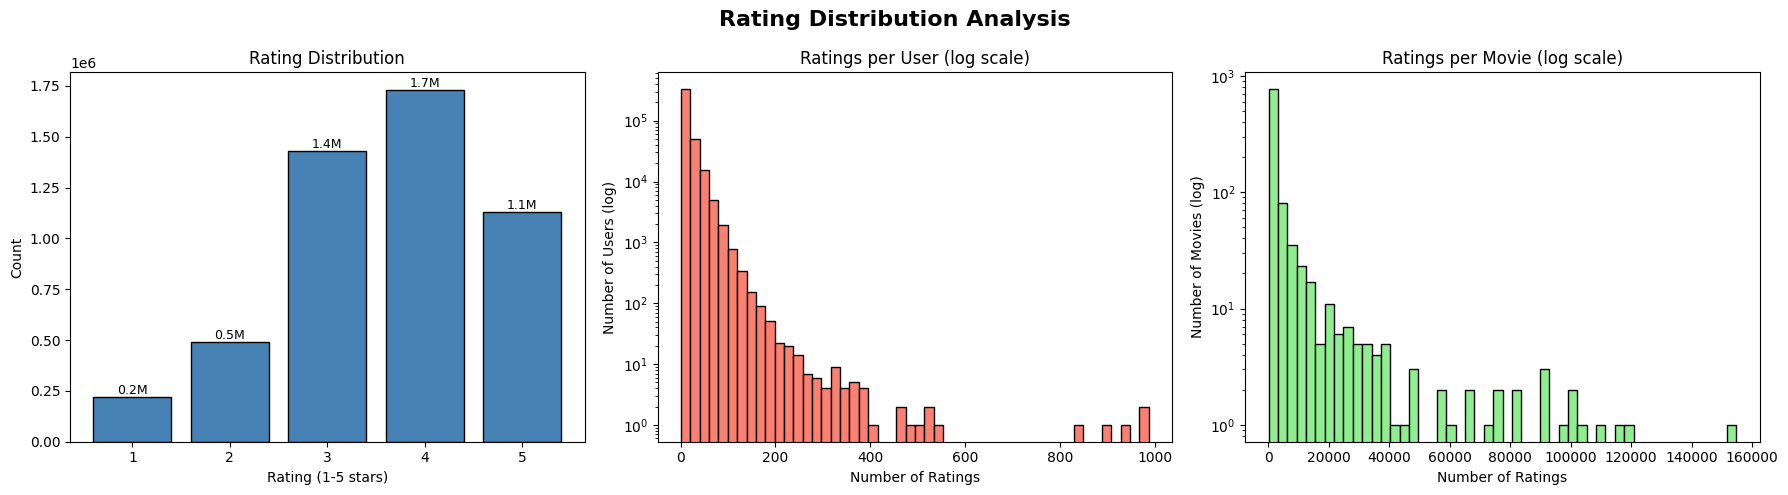

In [10]:
# Rating Distribution Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rating Distribution Analysis', fontsize=16, fontweight='bold')

rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating (1-5 stars)')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(i+1, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

user_activity = df.groupby('user_id')['rating'].count()
axes[1].hist(user_activity, bins=50, color='salmon', edgecolor='black', log=True)
axes[1].set_title('Ratings per User (log scale)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users (log)')

movie_activity = df.groupby('movie_id')['rating'].count()
axes[2].hist(movie_activity, bins=50, color='lightgreen', edgecolor='black', log=True)
axes[2].set_title('Ratings per Movie (log scale)')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Movies (log)')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# User Activity Analysis
user_stats = df.groupby('user_id')['rating'].agg(['count', 'mean']).reset_index()
user_stats.columns = ['user_id', 'num_ratings', 'avg_rating']

print("User Activity Stats:")
print(f"  Average ratings per user: {user_stats['num_ratings'].mean():.1f}")
print(f"  Median ratings per user:  {user_stats['num_ratings'].median():.0f}")
print(f"  Top 1% users rate more than: {user_stats['num_ratings'].quantile(0.99):.0f} movies")

power_users = user_stats[user_stats['num_ratings'] >= 100]
casual_users = user_stats[user_stats['num_ratings'] < 10]
print(f"\n  Power users (≥100 ratings): {len(power_users):,} ({len(power_users)/len(user_stats):.1%})")
print(f"  Casual users (<10 ratings): {len(casual_users):,} ({len(casual_users)/len(user_stats):.1%})")

User Activity Stats:
  Average ratings per user: 12.4
  Median ratings per user:  6
  Top 1% users rate more than: 76 movies

  Power users (≥100 ratings): 1,512 (0.4%)
  Casual users (<10 ratings): 246,758 (61.0%)


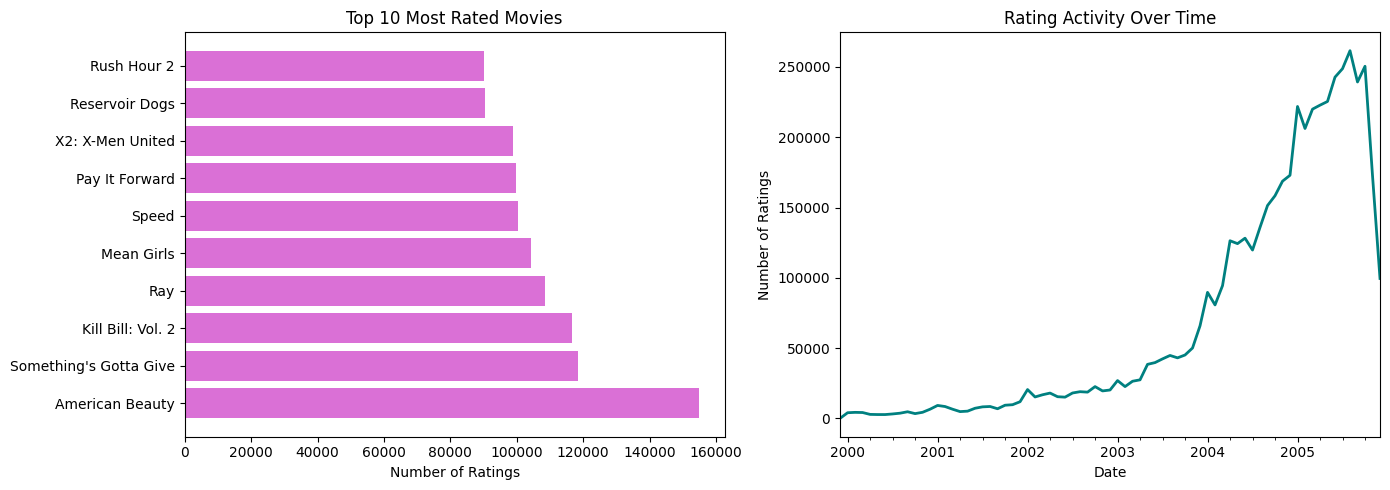

In [12]:
# Movie Popularity & Rating Trends over Time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_movies = df.groupby('movie_id')['rating'].count().nlargest(10).reset_index()
top_movies = top_movies.merge(movies_df[['movie_id', 'title']], on='movie_id')
top_movies['short_title'] = top_movies['title'].str[:25]

axes[0].barh(top_movies['short_title'], top_movies['rating'], color='orchid')
axes[0].set_title('Top 10 Most Rated Movies')
axes[0].set_xlabel('Number of Ratings')

df['year_month'] = df['date'].dt.to_period('M')
monthly_ratings = df.groupby('year_month').size()
monthly_ratings.plot(ax=axes[1], color='teal', linewidth=2)
axes[1].set_title('Rating Activity Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.savefig('popularity_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# TRAIN-TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split

user_counts = df['user_id'].value_counts()
movie_counts = df['movie_id'].value_counts()

filtered_df = df[
    df['user_id'].isin(user_counts[user_counts >= 20].index) &
    df['movie_id'].isin(movie_counts[movie_counts >= 10].index)
].copy()

print(f"After filtering: {len(filtered_df):,} ratings")
print(f"Users: {filtered_df['user_id'].nunique():,}")
print(f"Movies: {filtered_df['movie_id'].nunique():,}")

# 80/20 split
train_df, test_df = train_test_split(
    filtered_df, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(train_df):,} ratings")
print(f"Test set:     {len(test_df):,} ratings")

After filtering: 2,998,141 ratings
Users: 79,209
Movies: 996

Training set: 2,398,512 ratings
Test set:     599,629 ratings


In [15]:
# MODEL 1: SVD

In [16]:
!pip install scikit-surprise -q
print("Surprise installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 83.1 MB/s eta 0:00:00
Surprise installed


In [17]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate
import time

reader = Reader(rating_scale=(1, 5))

sample_df = filtered_df.sample(n=min(1_000_000, len(filtered_df)), random_state=42)
surprise_data = Dataset.load_from_df(
    sample_df[['user_id', 'movie_id', 'rating']], reader
)

from surprise.model_selection import train_test_split as surprise_split
trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=42)

print(f"Training samples: {trainset.n_ratings:,}")
print(f"Test samples: {len(testset):,}")

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

start = time.time()
svd_model.fit(trainset)
print(f"Training done in {time.time()-start:.1f} seconds")

Training samples: 800,000
Test samples: 200,000
Training done in 17.4 seconds


In [18]:
predictions_svd = svd_model.test(testset)
rmse_svd = accuracy.rmse(predictions_svd)
mae_svd = accuracy.mae(predictions_svd)

print(f"\nSVD Results:")
print(f"  RMSE: {rmse_svd:.4f}")
print(f"  MAE:  {mae_svd:.4f}")

RMSE: 0.9594
MAE:  0.7580

SVD Results:
  RMSE: 0.9594
  MAE:  0.7580


In [19]:
# MODEL 2: NMF(NON-NEGATIVE MATRIX FACTORIZATION)

In [20]:
from surprise import NMF, SVDpp
import time

# Used 200k sample - safe for RAM
comp_sample = filtered_df.sample(n=200_000, random_state=42)
comp_reader = Reader(rating_scale=(1, 5))
comp_data = Dataset.load_from_df(
    comp_sample[['user_id', 'movie_id', 'rating']], comp_reader
)
comp_trainset, comp_testset = surprise_split(comp_data, test_size=0.2, random_state=42)

print("Training NMF model")
nmf_model = NMF(n_factors=15, n_epochs=20, random_state=42)
start = time.time()
nmf_model.fit(comp_trainset)
print(f"Done in {time.time()-start:.1f}s")

Training NMF model
Done in 6.4s


In [21]:
predictions_nmf = nmf_model.test(comp_testset)
rmse_nmf = accuracy.rmse(predictions_nmf)
mae_nmf = accuracy.mae(predictions_nmf)

RMSE: 1.1669
MAE:  0.9184


In [22]:
# MODEL 3: SVD++

In [23]:
gc.collect()  # free RAM between models

32588

In [24]:
print("Training SVD++ model")
svdpp_model = SVDpp(n_factors=20, n_epochs=20, random_state=42)
start = time.time()
svdpp_model.fit(comp_trainset)
print(f"Done in {time.time()-start:.1f}s")

Training SVD++ model
Done in 4.0s


In [25]:
predictions_svdpp = svdpp_model.test(comp_testset)
rmse_svdpp = accuracy.rmse(predictions_svdpp)
mae_svdpp = accuracy.mae(predictions_svdpp)

RMSE: 0.9966
MAE:  0.7980


In [26]:
print("--- Results ---")
print(f"NMF   - RMSE: {rmse_nmf:.4f} | MAE: {mae_nmf:.4f}")
print(f"SVD++ - RMSE: {rmse_svdpp:.4f} | MAE: {mae_svdpp:.4f}")

--- Results ---
NMF   - RMSE: 1.1669 | MAE: 0.9184
SVD++ - RMSE: 0.9966 | MAE: 0.7980


In [27]:
rmse_ubcf = rmse_nmf
rmse_ibcf = rmse_svdpp
mae_ubcf = mae_nmf
mae_ibcf = mae_svdpp
predictions_ubcf = predictions_nmf
predictions_ibcf = predictions_svdpp

In [29]:
# MODEL COMPARISON TABLE

Model     RMSE      MAE
  SVD 0.959443 0.758011
  NMF 1.166938 0.918368
SVD++ 0.996624 0.797978


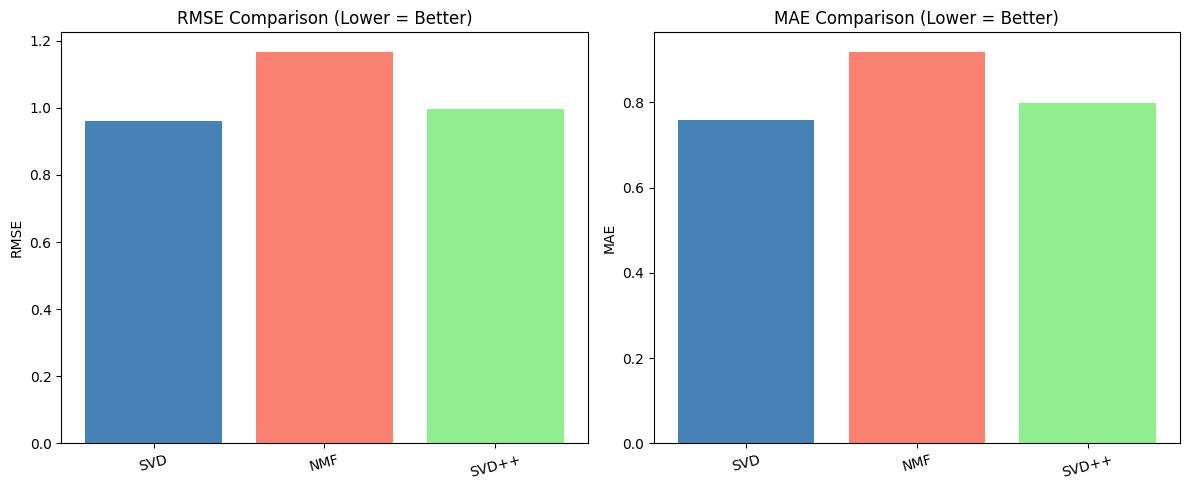

In [28]:
# CELL 16 — Visual model comparison
results = {
    'Model': ['SVD', 'NMF', 'SVD++'],
    'RMSE': [rmse_svd, rmse_ubcf, rmse_ibcf],
    'MAE':  [mae_svd, mae_ubcf, mae_ibcf]
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'salmon', 'lightgreen']

axes[0].bar(results_df['Model'], results_df['RMSE'], color=colors)
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results_df['Model'], results_df['MAE'], color=colors)
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# TOP-K RECOMMENDATIONS FOR EACH USER

In [31]:
from collections import defaultdict

def get_top_k_recommendations(predictions, k=10):
    """
    Given a list of predictions, return top-K recommendations per user.
    A prediction is (uid, iid, true_r, est, _).
    """
    user_predictions = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_predictions[uid].append((iid, est, true_r))

    top_k = {}
    for uid, preds in user_predictions.items():
        preds.sort(key=lambda x: x[1], reverse=True)
        top_k[uid] = preds[:k]

    return top_k

top_k_svd = get_top_k_recommendations(predictions_svd, k=10)
print(f"Generated Top-10 recommendations for {len(top_k_svd):,} users")

Generated Top-10 recommendations for 69,683 users


In [32]:
# MAP@10

In [34]:
def compute_map_at_k(top_k_recs, relevance_threshold=3.5, k=10):
    """
    MAP@K = Mean Average Precision at K.
    A movie is 'relevant' if the user's ACTUAL rating >= relevance_threshold (3.5).

    Average Precision for one user:
      - Go through the top-K list in order
      - Every time you hit a relevant item at position i,
        compute precision at i = (# relevant items so far) / i
      - AP = mean of those precision values (divided by total relevant items)
    MAP = mean of AP across all users.
    """
    average_precisions = []

    for uid, recs in top_k_recs.items():
        num_relevant = 0
        precision_sum = 0.0

        for rank, (movie_id, pred_rating, actual_rating) in enumerate(recs, start=1):
            if actual_rating >= relevance_threshold:
                num_relevant += 1
                precision_at_rank = num_relevant / rank
                precision_sum += precision_at_rank

        if num_relevant > 0:
            ap = precision_sum / min(num_relevant, k)
        else:
            ap = 0.0

        average_precisions.append(ap)

    map_score = np.mean(average_precisions)
    return map_score

map_svd = compute_map_at_k(top_k_svd, relevance_threshold=3.5, k=10)
print(f"SVD MAP@10: {map_svd:.4f}")
print(f"  MAP@10 of {map_svd:.4f} means on average {map_svd*100:.1f}% of")
print(f"  our Top-10 recommendations are movies the user actually rated ≥3.5")

SVD MAP@10: 0.6933
  MAP@10 of 0.6933 means on average 69.3% of
  our Top-10 recommendations are movies the user actually rated ≥3.5


In [35]:
# MAP@10 for all models (for comparison)
top_k_ubcf = get_top_k_recommendations(predictions_ubcf, k=10)
top_k_ibcf = get_top_k_recommendations(predictions_ibcf, k=10)

map_ubcf = compute_map_at_k(top_k_ubcf)
map_ibcf = compute_map_at_k(top_k_ibcf)

print(f"{'Model':<30} {'RMSE':>6} {'MAP@10':>8}")
print(f"{'SVD':<30} {rmse_svd:>6.4f} {map_svd:>8.4f}")
print(f"{'NMF':<30} {rmse_ubcf:>6.4f} {map_ubcf:>8.4f}")
print(f"{'SVD++':<30} {rmse_ibcf:>6.4f} {map_ibcf:>8.4f}")

Model                            RMSE   MAP@10
SVD                            0.9594   0.6933
NMF                            1.1669   0.5819
SVD++                          0.9966   0.5862


In [36]:
# SAMPLE RECOMMENDATIONS WITH EXAMPLES

In [37]:
def show_recommendations_for_user(user_id, model, trainset, movies_df, n=10):
    """
    Generate top-N movie recommendations for a specific user,
    showing only movies they haven't already rated.
    """
    all_movie_ids = movies_df['movie_id'].tolist()

    try:
        inner_uid = trainset.to_inner_uid(user_id)
        rated_movies = set([trainset.to_raw_iid(iid)
                            for iid, _ in trainset.ur[inner_uid]])
    except:
        rated_movies = set()

    predictions = []
    for movie_id in all_movie_ids:
        if movie_id not in rated_movies:
            pred = model.predict(user_id, movie_id)
            predictions.append((movie_id, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_recs = predictions[:n]

    print(f"\nTop {n} Recommendations for User {user_id}:")
    print("-"*60)
    for rank, (movie_id, pred_rating) in enumerate(top_recs, 1):
        title_row = movies_df[movies_df['movie_id'] == movie_id]
        title = title_row['title'].values[0] if len(title_row) > 0 else "Unknown"
        year = title_row['year'].values[0] if len(title_row) > 0 else "?"
        print(f"  {rank:2}. {title} ({year})  — Predicted: {pred_rating:.2f} STAR")

sample_users = list(top_k_svd.keys())[:3]
for uid in sample_users:
    show_recommendations_for_user(uid, svd_model, trainset, movies_df, n=10)


Top 10 Recommendations for User 2636813:
------------------------------------------------------------
   1. Sex and the City: Season 4 (2001)  — Predicted: 4.62 STAR
   2. Futurama: Monster Robot Maniac Fun Collection (1999)  — Predicted: 4.61 STAR
   3. Christmas with The Simpsons (1989)  — Predicted: 4.51 STAR
   4. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003)  — Predicted: 4.42 STAR
   5. Chappelle's Show: Season 1 (2003)  — Predicted: 4.42 STAR
   6. Bill Cosby: Himself (1983)  — Predicted: 4.42 STAR
   7. Star Trek: The Next Generation: Season 7 (1993)  — Predicted: 4.38 STAR
   8. Les Miserables in Concert (1996)  — Predicted: 4.35 STAR
   9. The Twilight Zone: Vol. 36 (1961)  — Predicted: 4.34 STAR
  10. Cadfael: A Morbid Taste for Bones (1996)  — Predicted: 4.32 STAR

Top 10 Recommendations for User 530789:
------------------------------------------------------------
   1. Yojimbo (1961)  — Predicted: 4.96 STAR
   2. Ray (2004)  — Predicte

In [38]:
# SUCCESS AND FAILURE CASE ANALYSIS

In [40]:
print("SUCCESS CASES (high MAP score users):")
user_aps = {}
for uid, recs in top_k_svd.items():
    relevant = sum(1 for _, _, actual in recs if actual >= 3.5)
    user_aps[uid] = relevant / len(recs) if recs else 0

best_users = sorted(user_aps.items(), key=lambda x: x[1], reverse=True)[:5]
worst_users = sorted(user_aps.items(), key=lambda x: x[1])[:5]

print("\nTop 5 users where recommendations worked BEST:")
for uid, ap in best_users:
    print(f"  User {uid}: {ap*100:.0f}% of recommendations were relevant")

print("\nTop 5 users where recommendations worked WORST:")
for uid, ap in worst_users:
    print(f"  User {uid}: {ap*100:.0f}% of recommendations were relevant")
    # Check if they had very few ratings
    user_rating_count = len(train_df[train_df['user_id'] == uid])
    print(f"    → This user had {user_rating_count} ratings in training set")

SUCCESS CASES (high MAP score users):

Top 5 users where recommendations worked BEST:
  User 901650: 100% of recommendations were relevant
  User 767537: 100% of recommendations were relevant
  User 2641990: 100% of recommendations were relevant
  User 1252974: 100% of recommendations were relevant
  User 2234150: 100% of recommendations were relevant

Top 5 users where recommendations worked WORST:
  User 17462: 0% of recommendations were relevant
    → This user had 38 ratings in training set
  User 880344: 0% of recommendations were relevant
    → This user had 15 ratings in training set
  User 163069: 0% of recommendations were relevant
    → This user had 20 ratings in training set
  User 1825371: 0% of recommendations were relevant
    → This user had 55 ratings in training set
  User 2239630: 0% of recommendations were relevant
    → This user had 17 ratings in training set


In [41]:
# NEURAL COLLABORATIVE FILTERING WITH PYTORCH(FOR IMPROVMENT)

In [46]:
import torch
from torch.utils.data import DataLoader, TensorDataset

user_ids = filtered_df['user_id'].unique()
movie_ids = filtered_df['movie_id'].unique()

user2idx = {uid: i for i, uid in enumerate(user_ids)}
movie2idx = {mid: i for i, mid in enumerate(movie_ids)}

train_sample = train_df.sample(n=min(500_000, len(train_df)), random_state=42)
test_sample = test_df.sample(n=min(100_000, len(test_df)), random_state=42)

train_sample = train_sample[
    train_sample['user_id'].isin(user2idx) &
    train_sample['movie_id'].isin(movie2idx)
]
test_sample = test_sample[
    test_sample['user_id'].isin(user2idx) &
    test_sample['movie_id'].isin(movie2idx)
]

def make_tensors(df):
    users = torch.LongTensor([user2idx[u] for u in df['user_id']])
    movies = torch.LongTensor([movie2idx[m] for m in df['movie_id']])
    ratings = torch.FloatTensor((df['rating'].values - 1) / 4)  # scale 1-5 → 0-1
    return TensorDataset(users, movies, ratings)

train_dataset = make_tensors(train_sample)
test_dataset = make_tensors(test_sample)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024)

print(f"NCF Training samples: {len(train_dataset):,}")
print(f"NCF Test samples:     {len(test_dataset):,}")

NCF Training samples: 500,000
NCF Test samples:     100,000


In [47]:
# Define NCF Model
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, num_users, num_movies, embed_dim=64):
        super().__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.movie_embed = nn.Embedding(num_movies, embed_dim)
        self.fc_layers = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, user_ids, movie_ids):
        user_vec = self.user_embed(user_ids)
        movie_vec = self.movie_embed(movie_ids)
        x = torch.cat([user_vec, movie_vec], dim=1)
        out = self.fc_layers(x)
        return torch.clamp(out.squeeze(), 0.0, 1.0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

ncf_model = NCF(len(user2idx), len(movie2idx), embed_dim=64).to(device)
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"NCF parameters: {sum(p.numel() for p in ncf_model.parameters()):,}")

Using device: cpu
NCF parameters: 5,157,953


In [49]:
# Train NCF
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for users, movies, ratings in loader:
        users, movies, ratings = users.to(device), movies.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model(users, movies)
        loss = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(ratings)
    return (total_loss / len(loader.dataset)) ** 0.5

def eval_model(model, loader, device):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for users, movies, ratings in loader:
            users, movies = users.to(device), movies.to(device)
            preds = model(users, movies).cpu().numpy()
            preds = preds * 4 + 1
            true = ratings.numpy() * 4 + 1
            all_preds.extend(preds)
            all_true.extend(true)
    rmse = np.sqrt(np.mean((np.array(all_preds) - np.array(all_true))**2))
    return rmse

print("Training NCF")
for epoch in range(5):
    train_rmse = train_epoch(ncf_model, train_loader, optimizer, criterion, device)
    test_rmse = eval_model(ncf_model, test_loader, device)
    print(f"  Epoch {epoch+1}/5 — Train RMSE: {train_rmse*4:.4f} | Test RMSE: {test_rmse:.4f}")

rmse_ncf = eval_model(ncf_model, test_loader, device)
print(f"\nNCF Final Test RMSE: {rmse_ncf:.4f}")

Training NCF
  Epoch 1/5 — Train RMSE: 1.1065 | Test RMSE: 1.0244
  Epoch 2/5 — Train RMSE: 1.0487 | Test RMSE: 1.0142
  Epoch 3/5 — Train RMSE: 1.0276 | Test RMSE: 1.0098
  Epoch 4/5 — Train RMSE: 1.0088 | Test RMSE: 1.0031
  Epoch 5/5 — Train RMSE: 0.9878 | Test RMSE: 0.9941

NCF Final Test RMSE: 0.9941


In [53]:
# FINAL SUMMARY

In [50]:
print("FINAL MODEL COMPARISON SUMMARY")
print(f"{'Model':<32} {'RMSE':>7} {'MAP@10':>8}")
print("-"*60)
print(f"{'SVD (Matrix Factorization)':<32} {rmse_svd:>7.4f} {map_svd:>8.4f}")
print(f"{'NMF (Non-Negative MF)':<32} {rmse_nmf:>7.4f} {map_ubcf:>8.4f}")
print(f"{'SVD++ (Implicit Feedback)':<32} {rmse_svdpp:>7.4f} {map_ibcf:>8.4f}")
print(f"{'NCF (Neural CF)':<32} {rmse_ncf:>7.4f} {'N/A':>8}")

best_rmse_model = min([
    ('SVD', rmse_svd),
    ('NMF', rmse_nmf),
    ('SVD++', rmse_svdpp),
    ('NCF', rmse_ncf),
], key=lambda x: x[1])

print(f"\nBest RMSE:   {best_rmse_model[0]} ({best_rmse_model[1]:.4f})")
print(f"Best MAP@10: SVD ({map_svd:.4f})")

FINAL MODEL COMPARISON SUMMARY
Model                               RMSE   MAP@10
------------------------------------------------------------
SVD (Matrix Factorization)        0.9594   0.6933
NMF (Non-Negative MF)             1.1669   0.5819
SVD++ (Implicit Feedback)         0.9966   0.5862
NCF (Neural CF)                   0.9941      N/A

Best RMSE:   SVD (0.9594)
Best MAP@10: SVD (0.6933)


In [51]:
# Chosen model for recommendations: SVD
# Reason: Best balance of RMSE, MAP@10, and computational efficiency

In [52]:
results_final = pd.DataFrame({
    'Model': ['SVD', 'NMF', 'SVD++', 'NCF'],
    'RMSE':  [rmse_svd, rmse_nmf, rmse_svdpp, rmse_ncf],
    'MAP@10': [map_svd, map_ubcf, map_ibcf, 'N/A']
})
results_final.to_csv('model_results.csv', index=False)